# Ex12 GRU vs LSTM predicting sin(a**2)

In [1]:
import torch
import torch.nn as nn
import torch.optim as opt
import numpy as np
import matplotlib.pyplot as plt

In [2]:
series = np.sin((0.1*np.arange(400))**2)

400


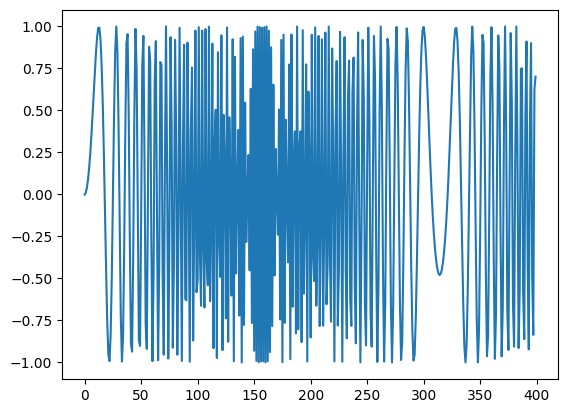

In [3]:
plt.plot(series)
print(len(series))
plt.show()

In [4]:
T = 10
D = 1 
M = 10
L = 1
N = len(series)
K = 1

## make the data

In [5]:
X,y = [],[]

for t in range(N-T):
    X.append(series[t:t+T])
    y.append(series[t+T])

X = np.array(X).reshape(-1,T,D)
y = np.array(y).reshape(-1,1)

In [6]:
X_train,X_test = X[:N//2],X[N//2:]
y_train,y_test = y[:N//2],y[N//2:]

In [7]:
X_train = torch.from_numpy(X_train.astype(np.float32))
X_test = torch.from_numpy(X_test.astype(np.float32))
y_train = torch.from_numpy(y_train.astype(np.float32))
y_test = torch.from_numpy(y_test.astype(np.float32))

## Model Classes

In [8]:
class GRU(nn.Module):
    def __init__(self, input_size,hidden_size,num_layers,output_size,bidirectional=False):
        super().__init__()
        self.D = input_size
        self.M = hidden_size
        self.L = num_layers
        self.K = output_size
        self.bidirectional = bidirectional

        self.rnn = nn.GRU(input_size=self.D,
                          hidden_size=self.M,
                          num_layers=self.L,
                          batch_first=True,
                          bidirectional=bidirectional)
        self.fc = nn.Linear(self.M*2 if self.bidirectional else self.M,
                            out_features=self.K)
        
    def forward(self,X):
        h0 = torch.zeros(self.L*2 if self.bidirectional else self.L,X.size(0),self.M).to(device)
        output,h_t = self.rnn(X,h0)
        #output shape NxTxM , 
        output = self.fc(output[:,-1,:]) # we  want the last time so it will be NxM
        #output now is NxK
        return output

In [9]:
class LSTMModel(nn.Module):
    def __init__(self, input_size,hidden_size,num_layers,output_size,bidirectional=False):
        super().__init__()
        self.D = input_size
        self.M = hidden_size
        self.L = num_layers
        self.K = output_size

        self.rnn = nn.LSTM(input_size=self.D,
                           hidden_size=self.M,
                           num_layers=self.L,
                           batch_first=True,
                           bidirectional=bidirectional)
        
        self.fc = nn.Linear(self.M,self.K)

    def forward(self,X):
        h0 = torch.zeros(self.L,X.size(0),self.M).to(device)
        c0 = torch.zeros(self.L,X.size(0),self.M).to(device)

        out,(h_t,c_t) = self.rnn(X,(h0,c0))
        #out is NxTxM , fc recieves NxM->NxK we take latest T
        out = self.fc(out[:,-1,:]) 
        return out

In [10]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")


In [11]:
X_train = X_train.to(device)
X_test = X_test.to(device)
y_train = y_train.to(device=device)
y_test = y_test.to(device)

In [12]:
def train_loop(model,optimizer:opt.Optimizer,creterion:nn.Module,epochs):
    train_loss = []
    val_loss = []
    lr_reduce_on_platau = opt.lr_scheduler.ReduceLROnPlateau(optimizer=optimizer,mode='min',patience=20)
    for epoch in range(epochs):
        optimizer.zero_grad()
        X_train.to(device)
        y_hat = model(X_train)
        loss = creterion(y_hat,y_train)
        loss.backward()
        optimizer.step()

        train_loss.append(loss.item())
        lr_reduce_on_platau.step(loss)

        #test
        y_hat = model(X_test)
        loss = creterion(y_hat,y_test)
        val_loss.append(loss.item())

        print(f'train loss {train_loss[-1]} test loss {val_loss[-1]}')

    return train_loss,val_loss

In [13]:
gru = GRU(D,M,L,K,False).to(device=device)
gru_criterion = nn.MSELoss()
gru_optimizer = opt.Adam(gru.parameters(),lr=0.05)

In [14]:
lstm = LSTMModel(D,M,L,K,False).to(device=device)
lstm_criterion = nn.MSELoss()
lstm_optimizer = opt.Adam(lstm.parameters(),lr=0.05)

In [15]:
epochs = 1000

In [16]:
gru_train_loss,gru_test_loss = train_loop(gru,gru_optimizer,gru_criterion,epochs)

train loss 0.5268234014511108 test loss 0.5235491394996643
train loss 0.5240930914878845 test loss 0.5406432747840881
train loss 0.5047791600227356 test loss 0.5889492630958557
train loss 0.5029661655426025 test loss 0.6335619688034058
train loss 0.49348658323287964 test loss 0.6769602298736572
train loss 0.4974643886089325 test loss 0.6861388087272644
train loss 0.49885112047195435 test loss 0.6660743951797485
train loss 0.49265962839126587 test loss 0.6370060443878174
train loss 0.48752638697624207 test loss 0.6106209754943848
train loss 0.4866781532764435 test loss 0.5895557403564453
train loss 0.485634446144104 test loss 0.5744812488555908
train loss 0.48109811544418335 test loss 0.5673419833183289
train loss 0.47405996918678284 test loss 0.5686134099960327
train loss 0.4645669460296631 test loss 0.5748348236083984
train loss 0.45105472207069397 test loss 0.5737905502319336
train loss 0.4332340955734253 test loss 0.5479211211204529
train loss 0.4061552584171295 test loss 0.50393724

In [17]:
lstm_train_losses,lstm_test_losses =train_loop(model=lstm,optimizer=lstm_optimizer,creterion=lstm_criterion,epochs=epochs)

train loss 0.5304396152496338 test loss 0.49292275309562683
train loss 0.531006932258606 test loss 0.49962329864501953
train loss 0.5196855068206787 test loss 0.5116416215896606
train loss 0.5087404847145081 test loss 0.5356000661849976
train loss 0.5018184781074524 test loss 0.5717704892158508
train loss 0.4979628324508667 test loss 0.6171731352806091
train loss 0.49504736065864563 test loss 0.6645336747169495
train loss 0.49482691287994385 test loss 0.6926980018615723
train loss 0.49604156613349915 test loss 0.6900569200515747
train loss 0.49408483505249023 test loss 0.6632516980171204
train loss 0.4885563552379608 test loss 0.626712441444397
train loss 0.48245230317115784 test loss 0.594111442565918
train loss 0.47855815291404724 test loss 0.5712905526161194
train loss 0.47544199228286743 test loss 0.557434618473053
train loss 0.4665544033050537 test loss 0.5511804819107056
train loss 0.4469813406467438 test loss 0.55844646692276
train loss 0.4430243670940399 test loss 0.52086979150

In [18]:
ticks = [x for x in range(epochs)]

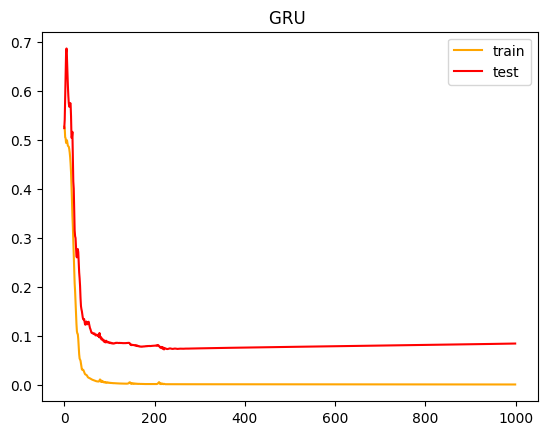

In [19]:
plt.title(f"GRU {'bidirectional' if gru.bidirectional else '' }")
plt.plot(gru_train_loss,color='orange',label='train')
plt.plot(gru_test_loss,color='red',label='test')
plt.legend()
plt.show()

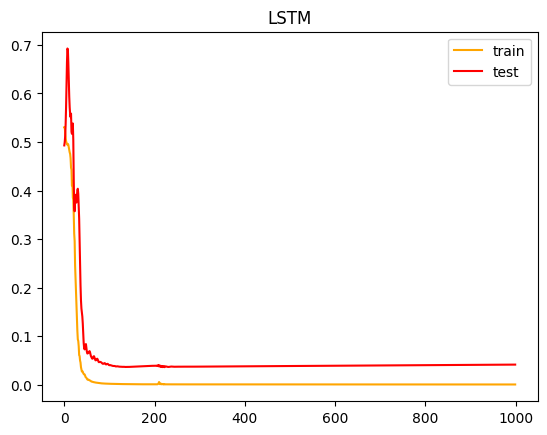

In [20]:
plt.title("LSTM")
plt.plot(lstm_train_losses,color='orange',label='train')
plt.plot(lstm_test_losses,color='red',label='test')
plt.legend()
plt.show()

In [21]:

times = len(y_test)

In [22]:
def predict_validation(model,X):
    X_last = X[0]
    predictions = []
    for i in range(times):
        X_last = X_last.view(1,T,D)
        pred = model(X_last)
        predictions.append(pred.item())
        X_last = torch.concat((X_last[-1,1:],pred))

    return predictions

In [23]:
gru_preds = predict_validation(model=gru,X=X_test)
lstm_preds = predict_validation(model=lstm,X=X_test)


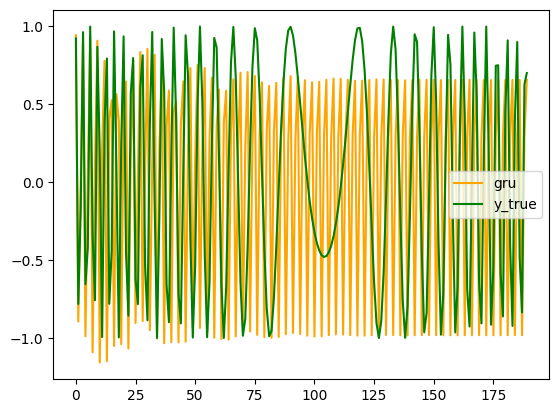

In [25]:
plt.plot(gru_preds,label='gru',color='orange')
plt.plot(y_test.detach().cpu().numpy(),label='y_true',color='green')

plt.legend()
plt.show()

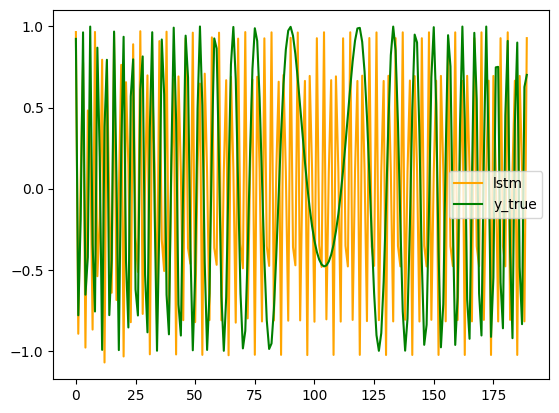

In [26]:
plt.plot(lstm_preds,label='lstm',color='orange')
plt.plot(y_test.detach().cpu().numpy(),label='y_true',color='green')

plt.legend()
plt.show()